In [1]:
import cv2
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

MM_TO_PT = 72 / 25.4
font_size_mm = 2.5
font_size_pt = font_size_mm * MM_TO_PT  # ≈ 8.5 pt
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": font_size_pt,
    "axes.labelsize": font_size_pt,
    "axes.titlesize": font_size_pt,
    "xtick.labelsize": font_size_pt,
    "ytick.labelsize": font_size_pt,
    "legend.fontsize": font_size_pt,
})

#### 6 bumps

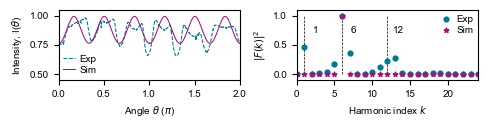

In [2]:
csv_dir = 'data'

colors=["#007894","#A7117A"] #petrol,purple

n_bump = '06'


exp_theta = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_exp_theta.csv', delimiter=',', dtype=float)
exp_prof_mean = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_exp_prof_mean.csv', delimiter=',', dtype=float)
exp_prof_std = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_exp_prof_std.csv', delimiter=',', dtype=float)
sim_theta = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_sim_theta.csv', delimiter=',', dtype=float)
sim_prof = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_sim_prof.csv', delimiter=',', dtype=float)


expK        = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_expK.csv', delimiter=',')
expMag      = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_expMag.csv', delimiter=',')
simK       = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_simK.csv', delimiter=',')
simMag     = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_simMag.csv', delimiter=',')

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(120/25.4,30/25.4))

# mean curve
ax1.plot(exp_theta, exp_prof_mean, '--', label="Exp", color=colors[0],linewidth=0.75)
ax1.plot(sim_theta, sim_prof, label="Sim", color=colors[1],linewidth=0.75)

# shaded ± std region
ax1.fill_between(
    exp_theta,
    exp_prof_mean - exp_prof_std,
    exp_prof_mean + exp_prof_std,
    alpha=0.25,
    color=colors[0], 
)



ax2.scatter(expK, expMag, s=12, color=colors[0], label='Exp')

ax2.scatter(simK, simMag, marker='*', s=12, color=colors[1], label='Sim', zorder=2)

ax2.plot(  [1,1],[0,1],'--', color='black',linewidth=0.5, zorder = -1)
ax2.plot(  [6,6],[0,1],'--', color='black',linewidth=0.5, zorder = -1)
ax2.plot([12,12],[0,1],'--', color='black',linewidth=0.5, zorder = -1)

ax2.text( 2.5, 0.75,  "1", ha='center', va='center')
ax2.text( 7.5, 0.75,  "6", ha='center', va='center')
ax2.text(13.5, 0.75, "12", ha='center', va='center')

ax1.set_xlabel(r"Angle $\theta$ ($\pi$)")
ax1.set_ylabel(r"Intensity, I($\theta$)")
ax1.set_xlim(0, 2)
ax1.set_ylim(0.45,1.05)

ax1.legend(
    frameon=False,
    handlelength=1.2,
    handletextpad=0.4,
    borderpad=0,
    labelspacing=0.2
)

ax2.set_xlim(0, 24)
ax2.set_ylim(-0.1,1.1)
ax2.set_xlabel(r"Harmonic index $k$")
ax2.set_ylabel(r"$|F(k)|^2$")

ax2.legend(
    frameon=False,
    handlelength=1.2,
    handletextpad=0.4,
    borderpad=0,
    labelspacing=0.2
)

from functools import partial

fig.tight_layout(pad=0.5)
plt.show()

#### 8 bumps

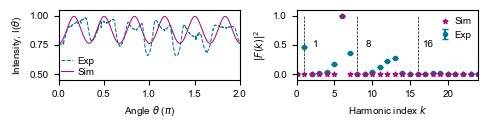

In [3]:

csv_dir = 'data'

exp_theta = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_exp_theta.csv', delimiter=',', dtype=float)
exp_prof_mean = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_exp_prof_mean.csv', delimiter=',', dtype=float)
exp_prof_std = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_exp_prof_std.csv', delimiter=',', dtype=float)
sim_theta = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_sim_theta.csv', delimiter=',', dtype=float)
sim_prof = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_sim_prof.csv', delimiter=',', dtype=float)

expK        = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_expK.csv', delimiter=',')
expMag_mean = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_expMag_mean.csv', delimiter=',')
expMag_std  = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_expMag_std.csv', delimiter=',')
simK       = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_simK.csv', delimiter=',')
simMag     = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_simMag.csv', delimiter=',')

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(120/25.4,30/25.4))

# mean curve
ax1.plot(exp_theta, exp_prof_mean, '--', label="Exp", color=colors[0],linewidth=0.75)
ax1.plot(sim_theta, sim_prof, label="Sim", color=colors[1],linewidth=0.75)

# shaded ± std region
ax1.fill_between(
    exp_theta,
    exp_prof_mean-exp_prof_std,
    exp_prof_mean+exp_prof_std,
    alpha=0.25,
    color=colors[0], 
)


ax2.errorbar(
    expK,
    expMag_mean,
    yerr=expMag_std,
    fmt='o',        # scatter points
    capsize=2,     # small caps on error bars
    color=colors[0],
    markersize=3,
    label='Exp',
    zorder=1
)

ax2.scatter(simK,simMag, marker='*', s=12, color=colors[1], label='Sim', zorder=2)

ax2.plot( [1,1],[0,1], '--', color='black',linewidth=0.5, zorder = -1)
ax2.plot( [8,8],[0,1], '--', color='black',linewidth=0.5, zorder = -1)
ax2.plot([16,16],[0,1],'--', color='black',linewidth=0.5, zorder = -1)

ax2.text( 2.5, 0.5,  "1", ha='center', va='center')
ax2.text( 9.5, 0.5,  "8", ha='center', va='center')
ax2.text(17.5, 0.5, "16", ha='center', va='center')

ax1.set_xlabel(r"Angle $\theta$ ($\pi$)")
ax1.set_ylabel(r"Intensity, I($\theta$)")
ax1.set_xlim(0, 2)
ax1.set_ylim(0.45,1.05)

ax1.legend(
    frameon=False,
    handlelength=1.2,
    handletextpad=0.4,
    borderpad=-.2,
    labelspacing=0.2
)


ax2.set_xlim(0, 24)
ax2.set_ylim([-0.1,1.1])
ax2.set_xlabel(r"Harmonic index $k$")
ax2.set_ylabel(r"$|F(k)|^2$")
ax2.legend(
    frameon=False,
    handlelength=1.5,
    handletextpad=0.2,
    borderpad=0.2,
    labelspacing=0.5
)

from functools import partial

fig.tight_layout(pad=0.5)
plt.show()

### 10 bumps

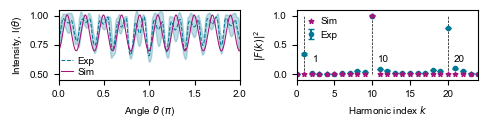

In [4]:
n_bump = '10'

exp_theta = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_exp_theta.csv', delimiter=',', dtype=float)
exp_prof_mean = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_exp_prof_mean.csv', delimiter=',', dtype=float)
exp_prof_std = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_exp_prof_std.csv', delimiter=',', dtype=float)
sim_theta = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_sim_theta.csv', delimiter=',', dtype=float)
sim_prof = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_sim_prof.csv', delimiter=',', dtype=float)


expK        = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_expK.csv', delimiter=',')
expMag_mean = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_expMag_mean.csv', delimiter=',')
expMag_std  = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_expMag_std.csv', delimiter=',')
simK       = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_simK.csv', delimiter=',')
simMag     = np.loadtxt(csv_dir+'/exp_fem_corr_'+n_bump+'_simMag.csv', delimiter=',')

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(120/25.4,30/25.4))

# mean curve
ax1.plot(exp_theta, exp_prof_mean, '--', label="Exp", color=colors[0],linewidth=0.75)
ax1.plot(sim_theta, sim_prof, label="Sim", color=colors[1],linewidth=0.75)

# shaded ± std region
ax1.fill_between(
    exp_theta,
    exp_prof_mean-exp_prof_std,
    exp_prof_mean+exp_prof_std,
    alpha=0.25,
    color=colors[0], 
)

ax2.errorbar(
    expK,
    expMag_mean,
    yerr=expMag_std,
    fmt='o',        # scatter points
    capsize=2,     # small caps on error bars
    color=colors[0],
    markersize=3,
    label='Exp',
    zorder=1
)

ax2.scatter(simK,simMag, marker='*', s=12, color=colors[1], label='Sim', zorder=2)

ax1.set_xlabel(r"Angle $\theta$ ($\pi$)")
ax1.set_ylabel(r"Intensity, I($\theta$)")
ax1.set_xlim(0, 2)
ax1.set_ylim([0.45,1.05])

ax1.legend(
    frameon=False,
    handlelength=1.2,
    handletextpad=0.4,
    borderpad=-.2,
    labelspacing=0.2
)

ax2.plot(  [1,1],[0,1],'--', color='black',linewidth=0.5, zorder = -1)
ax2.plot([10,10],[0,1],'--', color='black',linewidth=0.5, zorder = -1)
ax2.plot([20,20],[0,1],'--', color='black',linewidth=0.5, zorder = -1)

ax2.text( 2.5, 0.25,  "1", ha='center', va='center')
ax2.text(11.5, 0.25, "10", ha='center', va='center')
ax2.text(21.5, 0.25, "20", ha='center', va='center')

ax2.set_xlim(0, 24)
ax2.set_ylim([-0.1,1.1])

ax2.set_xlabel(r"Harmonic index $k$")
ax2.set_ylabel(r"$|F(k)|^2$")
ax2.legend(
    frameon=False,
    handlelength=1.5,
    handletextpad=0.2,
    borderpad=0.2,
    labelspacing=0.5
)

from functools import partial

fig.tight_layout(pad=0.5)
plt.show()
